In [14]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.append('../src')

from data_pipeline import load_all_raw_data
from data_analysis import (
    filter_data_until_date, temporal_split_data, 
    plot_user_analysis, plot_temporal_analysis, 
    plot_station_analysis, plot_activity_heatmap, 
    print_summary_statistics
)
from preprocess import (
    analyze_users_for_visualization, 
    analyze_trips_for_visualization,
    clean_dataset_comprehensive,
    clean_coordinate_columns,
    remove_baecobici_suffix,
    optimize_memory_usage
)


In [33]:

raw_data_dir = Path('../data/raw')
save_dir = Path('../data/raw/combined')

users_df, trips_df = load_all_raw_data(raw_data_dir, save_dir)

print(f"Datos cargados: {len(users_df):,} usuarios, {len(trips_df):,} viajes")


🚀 INICIANDO CARGA OPTIMIZADA DE DATOS RAW
👥 Cargando datos de usuarios...
Cargando: usuarios_ecobici_2020.csv
   ✓ 107,166 filas cargadas en 0.13s
Cargando: usuarios_ecobici_2021.csv
   ✓ 81,577 filas cargadas en 0.08s
Cargando: usuarios_ecobici_2022.csv
   ✓ 105,997 filas cargadas en 0.13s
Cargando: usuarios_ecobici_2023.csv
   ✓ 136,066 filas cargadas en 0.16s
Cargando: usuarios_ecobici_2024.csv
   ✓ 197,077 filas cargadas en 0.18s
🔗 Concatenando 5 archivos con 627,883 filas totales...
   ✓ Concatenación completada en 0.08s
   ⏱️ Usuarios cargados en 0.86 segundos
✅ Total usuarios: 627,883 registros
📊 Columnas usuarios: ['ID_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta', 'hora_alta', 'Customer.Has.Dni..Yes...No.', 'id_usuario']
💾 Memoria usuarios: 85.0 MB

🚲 Cargando datos de viajes...
Cargando: trips_2020.csv
   ✓ 2,415,597 filas cargadas en 13.46s
Cargando: trips_2021.csv
   ✓ 2,860,091 filas cargadas en 18.74s
Cargando: trips_2022.csv
   ✓ 2,922,805 filas cargadas en 21

In [17]:

# users_df = pd.read_csv('../data/raw/combined/users.csv')
# trips_df = pd.read_csv('../data/raw/combined/trips.csv')

In [34]:
print("Starting optimized preprocessing")
print("=" * 60)

print(f"Initial state:")
print(f"  - Users: {users_df.shape[0]:,} rows, {users_df.shape[1]} columns")
print(f"  - Trips: {trips_df.shape[0]:,} rows, {trips_df.shape[1]} columns")

print(f"\n1. Comprehensive cleaning...")
trips_df = clean_dataset_comprehensive(trips_df, verbose=True)

print(f"\n2. Geographic coordinates cleaning...")
coordinate_cols = ['lat_estacion_destino', 'long_estacion_destino', 
                   'lat_estacion_origen', 'long_estacion_origen']
trips_df = clean_coordinate_columns(trips_df, coordinate_cols, verbose=True)

print(f"\n3. Date preprocessing (before memory optimization)...")

# handle categorical fecha_alta column properly
print(f"Original users fecha_alta dtype: {users_df['fecha_alta'].dtype}")
if users_df['fecha_alta'].dtype.name == 'category':
    print("⚠️ Converting categorical fecha_alta to object first, then to datetime...")
    users_df['fecha_alta'] = users_df['fecha_alta'].astype(str)
    users_df['fecha_alta'] = pd.to_datetime(users_df['fecha_alta'], errors='coerce')
else:
    users_df['fecha_alta'] = pd.to_datetime(users_df['fecha_alta'], errors='coerce')

trips_df['fecha_origen_recorrido'] = pd.to_datetime(trips_df['fecha_origen_recorrido'], errors='coerce')

# verify date conversion before optimization
print(f"Date column types AFTER conversion, BEFORE optimization:")
print(f"  - users_df['fecha_alta']: {users_df['fecha_alta'].dtype}")
print(f"  - trips_df['fecha_origen_recorrido']: {trips_df['fecha_origen_recorrido'].dtype}")

print(f"\n4. Memory optimization (with datetime preservation)...")
trips_df = optimize_memory_usage(trips_df, verbose=True)
users_df = optimize_memory_usage(users_df, verbose=True)

# verify date columns are preserved as datetime after optimization
print(f"Date column types AFTER optimization:")
print(f"  - users_df['fecha_alta']: {users_df['fecha_alta'].dtype}")
print(f"  - trips_df['fecha_origen_recorrido']: {trips_df['fecha_origen_recorrido'].dtype}")


Starting optimized preprocessing
Initial state:
  - Users: 627,883 rows, 7 columns
  - Trips: 14,380,108 rows, 22 columns

1. Comprehensive cleaning...
🧹 Starting comprehensive cleaning for 14,380,108 rows...
   ✓ Merging gender columns...
   ✓ Merging ID columns...
   ✓ Processing BAEcobici suffixes for 4 columns...
     - Processing id_recorrido...
   ✓ Removing unnecessary columns...
✅ Comprehensive cleaning completed for 14,380,108 rows!

2. Geographic coordinates cleaning...
🗺️  BATCH COORDINATE CLEANING
   📊 Processing 14,380,108 rows...
🧭 Cleaning latitude column: lat_estacion_destino
   📊 Original nulls: 5,275,690
   📈 Values with comma (lat,lon): 0
   ✅ Valid latitudes: 9,104,418
   ⚠️ Final nulls: 5,275,690 (+0 from cleaning)
   📝 Sample cleaned values: [-34.572166, -34.597225, -34.620102, -34.60547, -34.583324]
🧭 Cleaning longitude column: long_estacion_destino
   📊 Original nulls: 43
   📈 Values with comma (lat,lon): 0
   ✅ Valid longitudes: 14,380,065
   ⚠️ Final nulls: 43

In [36]:

# ensure datetime types are correct before filtering
print(f"Final verification before filtering:")
print(f"  - users_df['fecha_alta']: {users_df['fecha_alta'].dtype}")
print(f"  - trips_df['fecha_origen_recorrido']: {trips_df['fecha_origen_recorrido'].dtype}")

print(f"\n5. Temporal filtering...")
users_filtered, trips_filtered = filter_data_until_date(
    users_df, trips_df, 
    max_date="2024-08-31",
    verbose=True
)

print(f"\n6. Temporal split...")
data_splits = temporal_split_data(
    users_filtered, trips_filtered,
    train_end_date="2023-06-30",  # Train until jun 2023
    val_end_date="2023-12-31",    # Val jul-dec 2023  
    test_end_date="2024-08-31",   # Test jan-aug 2024
    verbose=True
)

users_train = data_splits['users_train']
users_val = data_splits['users_val'] 
users_test = data_splits['users_test']

trips_train = data_splits['trips_train']
trips_val = data_splits['trips_val']
trips_test = data_splits['trips_test']

print(f"\nOptimized preprocessing completed!")
print(f"Users: Train={len(users_train):,}, Val={len(users_val):,}, Test={len(users_test):,}")
print(f"Trips: Train={len(trips_train):,}, Val={len(trips_val):,}, Test={len(trips_test):,}")
print(f"Final columns: {list(trips_train.columns)}")


Final verification before filtering:
  - users_df['fecha_alta']: datetime64[ns]
  - trips_df['fecha_origen_recorrido']: datetime64[ns]

5. Temporal filtering...
🔽 FILTERING DATA UNTIL 2024-08-31
   📊 Input: Users=627,883, Trips=14,380,108
   ⚡ Filtering users...
   ⚡ Filtering trips...
   ✅ Users: 627,883 → 546,010 (-81,873)
   ✅ Trips: 14,380,108 → 12,976,053 (-1,404,055)

6. Temporal split...
🔄 OPTIMIZED TEMPORAL SPLIT
   📅 Train ≤ 2023-06-30 | Val: 2023-06-30 - 2023-12-31 | Test: 2023-12-31 - 2024-08-31
   📊 Input: Users=546,010, Trips=12,976,053
   ⚡ Splitting users...
   ⚡ Splitting trips...
   ✅ Users: Train=346,517, Val=84,289, Test=115,204
   ✅ Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103

Optimized preprocessing completed!
Users: Train=346,517, Val=84,289, Test=115,204
Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103
Final columns: ['duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_e

📊 GENERANDO ANÁLISIS PARA VISUALIZACIÓN...
⏱️ Tiempo de análisis: 9.86 segundos

📊 ESTADÍSTICAS DE ENTRENAMIENTO:
   • Usuarios en train: (346517, 7)
   • Viajes en train: (9505149, 17)

📈 Generando análisis de usuarios...


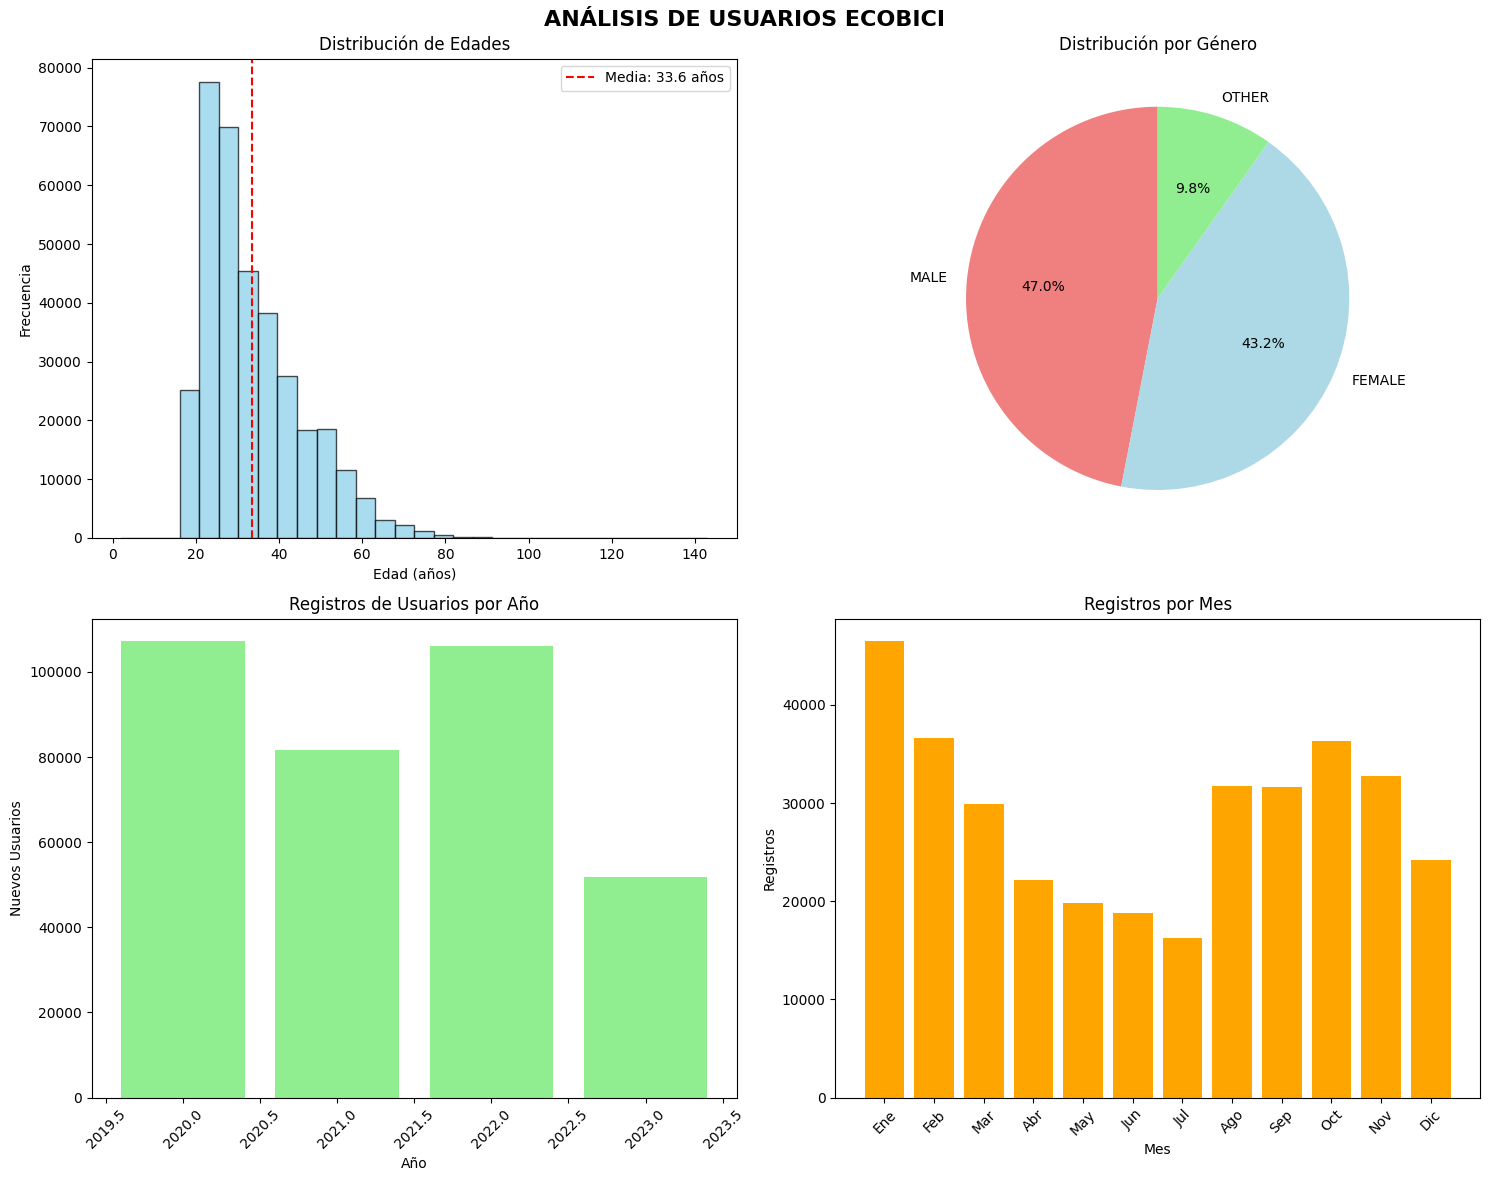

📈 Generando análisis temporal...


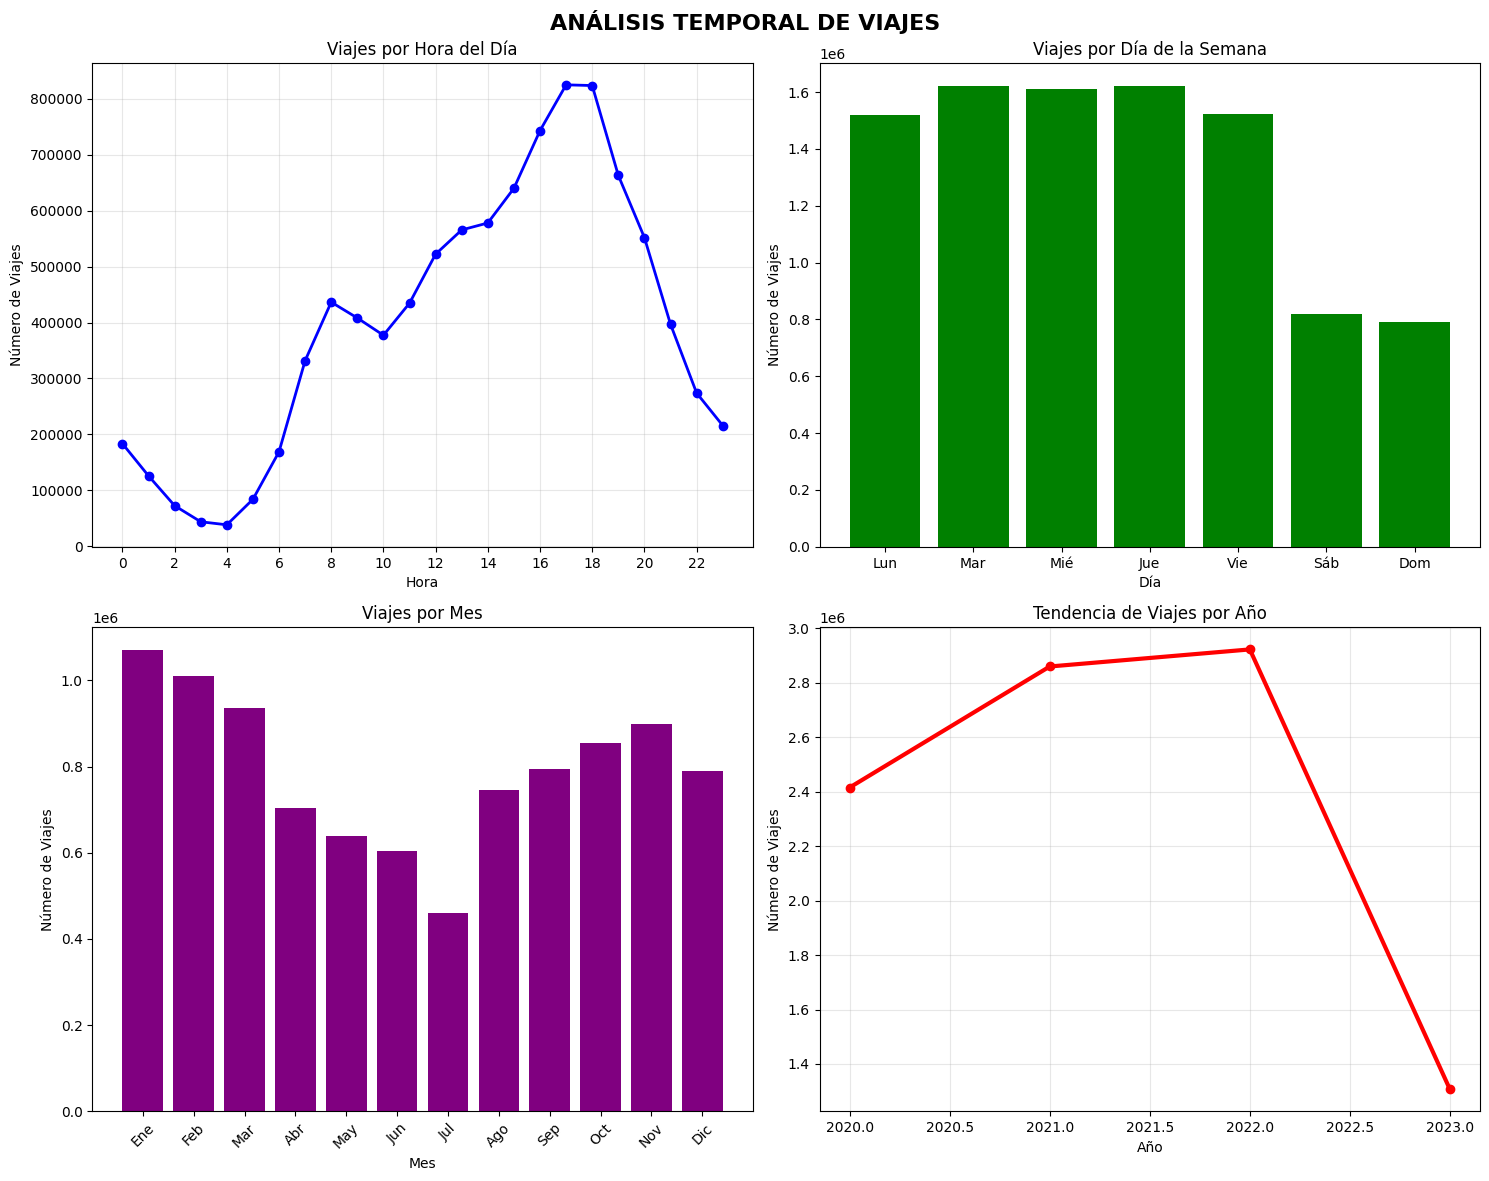

📈 Generando análisis de estaciones...


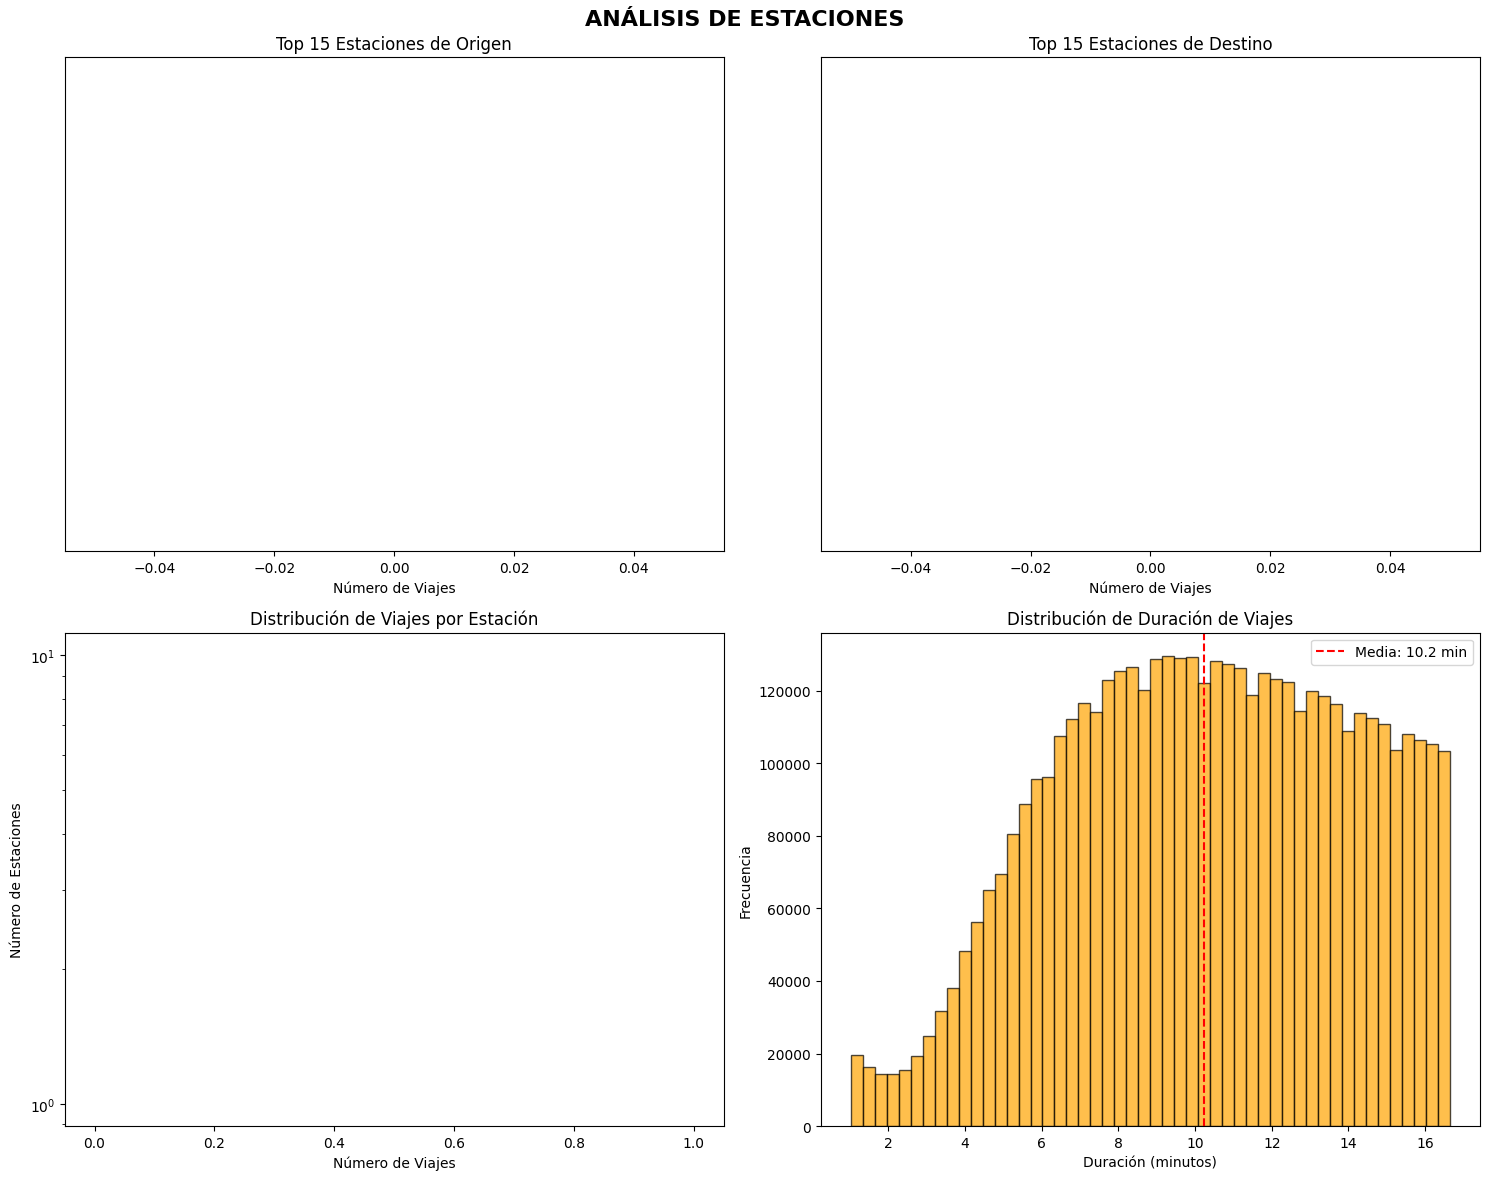

📈 Generando heatmap de actividad...


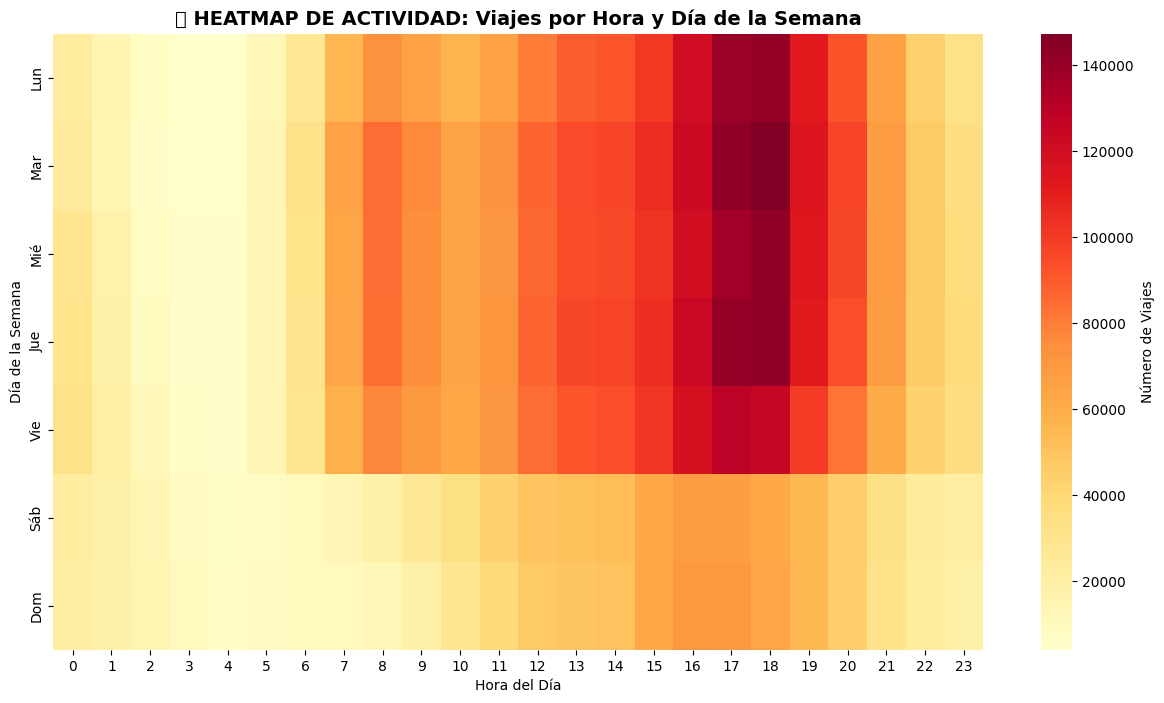


📊 ESTADÍSTICAS RESUMEN
👥 USUARIOS:
   • Total usuarios: 546,010
   • Edad promedio: 33.6 años
   • Distribución de género:
     - MALE: 162,712 (29.8%)
     - FEMALE: 149,785 (27.4%)
     - OTHER: 34,018 (6.2%)

🚲 VIAJES:
   • Total viajes: 12,976,053
   • Período: 2020-01-01 00:00:08 - 2023-06-29 23:59:55
   • Promedio viajes/día: 10,169
   • Estaciones únicas (origen): 0
   • Estaciones únicas (destino): 0
   • Duración promedio: 10.2 minutos


In [37]:
# ANÁLISIS Y VISUALIZACIÓN OPTIMIZADA
print("📊 GENERANDO ANÁLISIS PARA VISUALIZACIÓN...")
analysis_start = time.time()

# Analizar usuarios y viajes del set de entrenamiento usando funciones optimizadas
processed_users = analyze_users_for_visualization(users_train)
processed_trips = analyze_trips_for_visualization(trips_train)

analysis_time = time.time() - analysis_start
print(f"⏱️ Tiempo de análisis: {analysis_time:.2f} segundos")

print(f"\n📊 ESTADÍSTICAS DE ENTRENAMIENTO:")
print(f"   • Usuarios en train: {users_train.shape}")
print(f"   • Viajes en train: {trips_train.shape}")

# Generar visualizaciones
print("\n📈 Generando análisis de usuarios...")
plot_user_analysis(processed_users, save_plots=False, output_dir=None)

print("📈 Generando análisis temporal...")
plot_temporal_analysis(processed_trips, save_plots=False, output_dir=None)

print("📈 Generando análisis de estaciones...")
plot_station_analysis(processed_trips, save_plots=False, output_dir=None)

print("📈 Generando heatmap de actividad...")
plot_activity_heatmap(processed_trips, save_plots=False, output_dir=None)

print_summary_statistics(users_filtered, processed_users, trips_filtered, processed_trips)


In [8]:
# verificar el estado final de los datos después del preproceso
print("📋 VERIFICACIÓN FINAL DE DATOS")
print("=" * 40)

print(f"\n📊 RESUMEN DE DATASETS:")
print(f"  • Train: {len(trips_train):,} viajes, {len(trips_train.columns)} columnas")
print(f"  • Val: {len(trips_val):,} viajes, {len(trips_val.columns)} columnas") 
print(f"  • Test: {len(trips_test):,} viajes, {len(trips_test.columns)} columnas")

print(f"\n🔍 VERIFICACIÓN DE LIMPIEZA:")
# check data types of key columns
key_columns = ['id_estacion_origen', 'id_estacion_destino', 'id_usuario', 'id_recorrido']
for col in key_columns:
    if col in trips_train.columns:
        dtype = trips_train[col].dtype
        sample_val = trips_train[col].dropna().iloc[0] if len(trips_train[col].dropna()) > 0 else "N/A"
        print(f"  ✓ {col}: {dtype} (ej: {sample_val})")

# check gender column
if 'genero' in trips_train.columns:
    gender_dist = trips_train['genero'].value_counts()
    print(f"  ✓ genero: {len(gender_dist)} valores únicos - {dict(gender_dist.head(3))}")

print(f"\n🚫 VERIFICACIÓN DE COLUMNAS ELIMINADAS:")
original_problematic = ['Unnamed: 0', 'X', 'género', 'Género', 'Id_recorrido']
still_present = [col for col in original_problematic if col in trips_train.columns]
if still_present:
    print(f"  ⚠️ Aún presentes: {still_present}")
else:
    print(f"  ✅ Todas las columnas problemáticas fueron eliminadas correctamente")

print(f"\n✅ Datos listos para análisis y modelado!")


📋 VERIFICACIÓN FINAL DE DATOS

📊 RESUMEN DE DATASETS:
  • Train: 9,505,149 viajes, 17 columnas
  • Val: 1,312,801 viajes, 17 columnas
  • Test: 2,158,103 viajes, 17 columnas

🔍 VERIFICACIÓN DE LIMPIEZA:
  ✓ id_estacion_origen: Int64 (ej: 27)
  ✓ id_estacion_destino: Int64 (ej: 3)
  ✓ id_usuario: Int64 (ej: 192009)
  ✓ id_recorrido: Int64 (ej: 7210548)
  ✓ genero: 3 valores únicos - {'MALE': np.int64(5050284), 'FEMALE': np.int64(3083226), 'OTHER': np.int64(1313333)}

🚫 VERIFICACIÓN DE COLUMNAS ELIMINADAS:
  ✅ Todas las columnas problemáticas fueron eliminadas correctamente

✅ Datos listos para análisis y modelado!


In [27]:
trips_df.head()

,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,id_recorrido,genero
0,"1,582",2020-01-24 21:54:39,27,027 - Montevideo,Cordoba Av. & Montevideo,-58.390087,-34.599068,2020-01-24 22:21:01,3,003 - ADUANA,Moreno & Av Paseo Colon,-34.611031,-34.611031,192009,ICONIC,7210548,FEMALE
1,204,2020-01-24 07:04:19,151,151 - AIME PAINÉ,"Villaflor, Azucena & Paine, Aime",-58.361286,-34.611816,2020-01-24 07:07:43,3,003 - ADUANA,Moreno & Av Paseo Colon,-34.611031,-34.611031,36380,ICONIC,7199093,MALE
2,"1,790",2020-01-24 00:15:17,111,111 - MACACHA GUEMES,Machaca Guemes 350,-58.364685,-34.605488,2020-01-24 00:45:07,3,003 - ADUANA,Moreno & Av Paseo Colon,-34.611031,-34.611031,460080,ICONIC,7196805,MALE
3,"10,688",2020-01-24 12:38:16,285,400 - Reserva Ecologica,"Achaval Rodriguez, T., Dr. Av. 1520",-58.356174,-34.617210,2020-01-24 15:36:24,4,004 - Plaza Roma,Lavalle & Bouchard,-34.601822,-34.601822,3857,ICONIC,7203598,MALE
4,673,2020-01-24 08:31:01,171,171 - Pasteur,519 Pasteur,-58.399754,-34.603283,2020-01-24 08:42:14,7,007 - OBELISCO,CARLOS PELEGRINI 215,-34.606499,-34.606499,391034,ICONIC,7200335,FEMALE


In [ ]:
users_df.to_csv('../data/raw/combined/users.csv', index=False)
trips_df.to_csv('../data/raw/combined/trips.csv', index=False)